<a href="https://colab.research.google.com/github/bigbirdjones/laguardia_data_analytics/blob/main/NYC_Cooling_Tower_System_Inspection_Results_EDA.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Primary Questions**:
#Who were the largest individual violators of Chapter 8, Title 24 of RCNY between 2015 & 2025?       
#What were the top violation types citywide?

# Step 1: LOAD THE DATA

## Main Dataset

I'll load my main dataset from NYC Open Data via API in 3 segments, then concatinate to create a full DataFrame.

My main dataset is the result of inspections conducted by the Department of Health & Mental Hygiene (DOHMH) on cooling towers for large HVAC installations around the city.

These violations are covered by Chapter 8 of Title 24 of the Rules of The City of New York. (24 RCNY)

In [ ]:
import pandas as pd

In [ ]:
URL = "https://data.cityofnewyork.us/resource/f9wb-g8mb.csv?$limit=50000"

df1 = pd.read_csv(URL)

/tmp/ipykernel_5472/2484009375.py:3: DtypeWarning: Columns (4) have mixed types. Specify dtype option on import or set low_memory=False.
  df1 = pd.read_csv(URL)


In [ ]:
URL = "https://data.cityofnewyork.us/resource/f9wb-g8mb.csv?$limit=50000&$offset=50000"

df2 = pd.read_csv(URL)

In [ ]:
URL = "https://data.cityofnewyork.us/resource/f9wb-g8mb.csv?$limit=22846&$offset=100000"

df3 = pd.read_csv(URL)

In [ ]:
full_df = pd.concat([df1, df2, df3])
full_df

,bin,system_id,address,borough,zip_code,status,active_equip,inspection_date,violation_code,law_section,...,citation_text,summons_number,inspection_type,bbl,latitude,longitude,community_board,council_district,census_tract,nta_code
0,1015834,2000000122,1271 BROADWAY,Manhattan,10001,Inactive,0,2021-05-21T00:00:00.000,AH8U,24 RCNY §8-05(f)(5),...,NaN,196816281.0,Non-Cycle,1008330078,40.748260,-73.988491,105.0,3.0,7600.0,MN0501
1,1015834,2000000122,1271 BROADWAY,Manhattan,10001,Inactive,0,2021-05-21T00:00:00.000,AH8C,24 RCNY §8-04(a),...,Respondent is in violation of 24 RCNY 8-04(a)(...,881249959.0,Cycle,1008330078,40.748260,-73.988491,105.0,3.0,7600.0,MN0501
2,1015834,2000000122,1271 BROADWAY,Manhattan,10001,Inactive,0,2021-05-21T00:00:00.000,AH8D,24 RCNY §8-04(b),...,Compliance inspections must be completed by a ...,881249968.0,Cycle,1008330078,40.748260,-73.988491,105.0,3.0,7600.0,MN0501
3,1015834,2000000122,1271 BROADWAY,Manhattan,10001,Inactive,0,2021-05-21T00:00:00.000,AH8E,24 RCNY §8-04(c),...,"At the time of inspection, operational records...",NaN,Cycle,1008330078,40.748260,-73.988491,105.0,3.0,7600.0,MN0501
4,1015834,2000000122,1271 BROADWAY,Manhattan,10001,Inactive,0,2021-05-21T00:00:00.000,AH8L,24 RCNY §8-05(c)(3),...,"At the time of inspection, upon Inspector's re...",881249977.0,Cycle,1008330078,40.748260,-73.988491,105.0,3.0,7600.0,MN0501
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
22841,1032434,2000010244,175 W 89TH ST,Manhattan,10024,Active,1,2026-03-13T00:00:00.000,AH8X,24 RCNY §8-06(b)(2),...,"At the time of inspection, Respondent failed t...",881335813.0,Cycle,1012200005,40.789232,-73.972688,107.0,6.0,17300.0,MN0702
22842,1003483,2000000680,16 E BROADWAY,Manhattan,10002,Active,1,2026-03-13T00:00:00.000,NaN,NaN,...,NaN,NaN,Cycle,1002810006,40.713513,-73.996775,103.0,1.0,800.0,MN0301
22843,1012280,2000004083,555 WEST 18 STREET,Manhattan,NaN,Active,4,2026-03-13T00:00:00.000,NaN,NaN,...,NaN,NaN,Cycle,1006900012,40.745570,-74.007698,NaN,NaN,9901.0,MN0401
22844,1013552,2000003450,315 W 33RD ST,Manhattan,10001,Active,2,2026-03-13T00:00:00.000,NaN,NaN,...,NaN,NaN,Cycle,1007570022,40.751824,-73.994651,104.0,3.0,10300.0,MN0401


## Auxiliary Dataset

Next i'll load my auxiliary dataset, which after cleaning I will merge with the main dataset.

These records are derived from the Office of Administrative Trials & Hearings.

They have +20 Million records spanning over a decade, so I queried the records on NYC Open Data to get only the ones from the issuing agency i'm looking for, which is 'COOLING TOWERS - DOHMH', and downloaded the results in a csv.




In [ ]:
URL2 = "/content/drive/MyDrive/NYC Cooling Tower EDA Capstone/OATH_Hearings_Division_Case_Status_20260409.csv"
oath_df = pd.read_csv(URL2)

/tmp/ipykernel_5472/2915690999.py:2: DtypeWarning: Columns (31,42,43,44,45,46,47,48,49) have mixed types. Specify dtype option on import or set low_memory=False.
  oath_df = pd.read_csv(URL2)


I'm dropping these columns immediately because they are obviously empty from even a cursory glance at the spreadsheet.

They are for charges 2 thru 10, but in the cases i'm looking at, the DOHMH seems to have only issued a single charge per ticketed violation, so it's one charge per row.

OATH handles administrative hearings for multiple city agencies, so it makes sense to leave space, but goodbye empty columns!

In [ ]:
# These columns are obviously empty, so they are being dropped immediately.

In [ ]:
oath_df = oath_df.drop(oath_df.columns[[42,43,44,45,46,47,48,49,50,
                                        51,52,53,54,55,56,57,58,59,60,
                                        61,62,63,64,65,66,67,68,69,70,
                                        71,72,73,74,75,76,77]], axis=1)

(I know this is technically cleaning, but it's my notebook and I'll decide where the title breaks go... speaking of which)

#Step 2: CLEAN THE DATA

## Dropping NaN's

In [ ]:
import seaborn as sns

<Axes: >

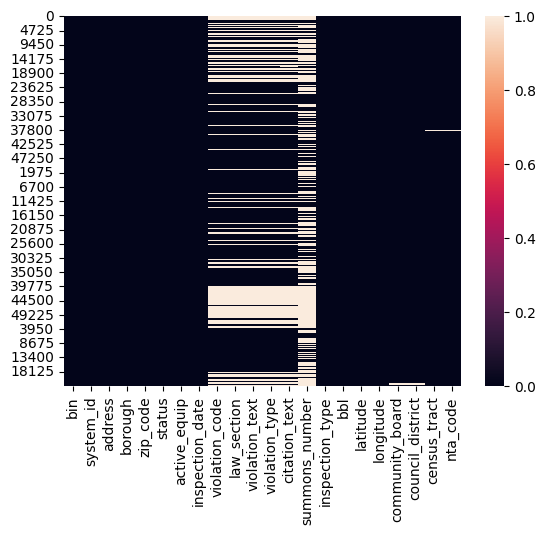

In [ ]:
sns.heatmap(full_df.isnull())

First, anyone who wasn't issued a violation I'm not interested in, so NaN's in the **'violation_code'** column are my first target.

In [ ]:
full_df["violation_code"].isnull().sum()

np.int64(34364)

In [ ]:
full_df.dropna(subset="violation_code", inplace= True)

In [ ]:
print(122846-34364)

88482


Next, the **'summons_number'** is how I'm linking my main data set with the **'Ticket Number'** in the auxiliary dataset, so NaN's there need to be dealt with as well.

In [ ]:
full_df['summons_number'].isnull().sum()

np.int64(33796)

In [ ]:
full_df.dropna(subset='summons_number', inplace= True)

In [ ]:
print(88482-33796)

54686


Then a quick datatype recast from float64 to Int64 so the key columns will match.

In [ ]:
# A quick datatype recast from float64 to Int64 so the key columns will match.

In [ ]:
full_df['summons_number'] = full_df['summons_number'].astype(int)

In [ ]:
full_df

,bin,system_id,address,borough,zip_code,status,active_equip,inspection_date,violation_code,law_section,...,citation_text,summons_number,inspection_type,bbl,latitude,longitude,community_board,council_district,census_tract,nta_code
0,1015834,2000000122,1271 BROADWAY,Manhattan,10001,Inactive,0,2021-05-21T00:00:00.000,AH8U,24 RCNY §8-05(f)(5),...,NaN,196816281,Non-Cycle,1008330078,40.748260,-73.988491,105.0,3.0,7600.0,MN0501
1,1015834,2000000122,1271 BROADWAY,Manhattan,10001,Inactive,0,2021-05-21T00:00:00.000,AH8C,24 RCNY §8-04(a),...,Respondent is in violation of 24 RCNY 8-04(a)(...,881249959,Cycle,1008330078,40.748260,-73.988491,105.0,3.0,7600.0,MN0501
2,1015834,2000000122,1271 BROADWAY,Manhattan,10001,Inactive,0,2021-05-21T00:00:00.000,AH8D,24 RCNY §8-04(b),...,Compliance inspections must be completed by a ...,881249968,Cycle,1008330078,40.748260,-73.988491,105.0,3.0,7600.0,MN0501
4,1015834,2000000122,1271 BROADWAY,Manhattan,10001,Inactive,0,2021-05-21T00:00:00.000,AH8L,24 RCNY §8-05(c)(3),...,"At the time of inspection, upon Inspector's re...",881249977,Cycle,1008330078,40.748260,-73.988491,105.0,3.0,7600.0,MN0501
7,1015834,2000000122,1271 BROADWAY,Manhattan,10001,Inactive,0,2021-05-21T00:00:00.000,AH8S,24 RCNY §8-05(f)(3),...,"At the time of inspection, records provided by...",881249986,Cycle,1008330078,40.748260,-73.988491,105.0,3.0,7600.0,MN0501
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
22834,1079280,2000015740,88 CENTRAL PARK WEST,Manhattan,10023,Active,2,2026-03-13T00:00:00.000,AH8X,24 RCNY §8-06(b)(2),...,"At the time of inspection, Respondent failed t...",881335923,Cycle,1011210036,40.774202,-73.977850,NaN,NaN,15301.0,MN0701
22838,1032434,2000010244,175 W 89TH ST,Manhattan,10024,Active,1,2026-03-13T00:00:00.000,AH8D,24 RCNY §8-04(b),...,Compliance inspections must be completed by a ...,881335777,Cycle,1012200005,40.789232,-73.972688,107.0,6.0,17300.0,MN0702
22839,1032434,2000010244,175 W 89TH ST,Manhattan,10024,Active,1,2026-03-13T00:00:00.000,AH8S,24 RCNY §8-05(f)(3),...,"At the time of inspection, Respondent failed t...",881335795,Cycle,1012200005,40.789232,-73.972688,107.0,6.0,17300.0,MN0702
22840,1032434,2000010244,175 W 89TH ST,Manhattan,10024,Active,1,2026-03-13T00:00:00.000,AH8W,24 RCNY §8-06(b)(1),...,"At the time of inspection, records provided by...",881335804,Cycle,1012200005,40.789232,-73.972688,107.0,6.0,17300.0,MN0702


<Axes: >

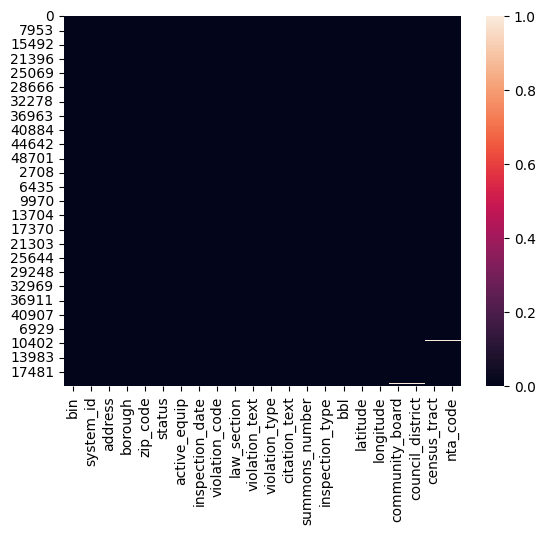

In [ ]:
sns.heatmap(full_df.isnull())

In [ ]:
oath_df

,Ticket Number,Violation Date,Violation Time,Issuing Agency,Respondent First Name,Respondent Last Name,Balance Due,Violation Location (Borough),Violation Location (Block No.),Violation Location (Lot No.),...,Respondent Address or Facility Number(For FDNY and DOB Tickets),Penalty Imposed,Paid Amount,Additional Penalties or Late Fees,Compliance Status,Violation Description,Charge #1: Code,Charge #1: Code Section,Charge #1: Code Description,Charge #1: Infraction Amount
0,193687506,NaN,10:30:00,COOLING TOWERS - DOHMH,NaN,EIB KEITREL LLC,$0.00,BROOKLYN,5320.0,24.0,...,NaN,$0.00,$0.00,$0.00,All Terms Met,NaN,AH7A,24RCNY31-02 A,FAIL TO SUBMIT REPORT OF PREVIOUS YEAR'S INSPE...,$250.00
1,193688193,NaN,10:30:00,COOLING TOWERS - DOHMH,NaN,919,$0.00,MANHATTAN,300.0,10.0,...,NaN,$0.00,$0.00,$0.00,All Terms Met,NaN,AH7A,24RCNY31-02 A,FAIL TO SUBMIT REPORT OF PREVIOUS YEAR'S INSPE...,$250.00
2,193662087,NaN,09:52:00,COOLING TOWERS - DOHMH,NaN,ST BARTHOLOMEWS CHURCH,$0.00,MANHATTAN,1305.0,1.0,...,NaN,$0.00,$0.00,$0.00,All Terms Met,NaN,AH8C,24RCNY8-04 A,"ROUTINE MONIT NOT CONDUCT,DOC'D AT LEAST ONCE ...",$500.00
3,193677267,NaN,10:30:00,COOLING TOWERS - DOHMH,NaN,55 LIBERTY OWNERS CORP,$0.00,MANHATTAN,64.0,8.0,...,NaN,$0.00,$0.00,$0.00,All Terms Met,NaN,AH7A,24RCNY31-02 A,FAIL TO SUBMIT REPORT OF PREVIOUS YEAR'S INSPE...,$250.00
4,193671812,NaN,09:54:00,COOLING TOWERS - DOHMH,NaN,ANDREW J TUNICK AS TRUSTEE,$0.00,MANHATTAN,867.0,1.0,...,NaN,$0.00,$0.00,$0.00,All Terms Met,NaN,AH8B,24RCNY8-03,MAINTENANCE PROGRAM AND PLAN INCOMPLETE OR NOT...,$500.00
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
58333,880698390,09/21/2015,13:34:00,COOLING TOWERS - DOHMH,NaN,STERLING LANDLORD CORP,$0.00,MANHATTAN,1022.0,35.0,...,NaN,"$2,000.00","$2,000.00",$0.00,All Terms Met,NaN,AH3K,NYCHC 3.05,"FAILING TO COMPLY WITH DEPT, BOARD OF HEALTH, ...","$1,000.00"
58334,880698345,09/21/2015,13:34:00,COOLING TOWERS - DOHMH,NaN,261 FIFTH AVENUE TIC,"$2,000.00",MANHATTAN,858.0,78.0,...,NaN,"$2,000.00",$0.00,$0.00,Penalty Due,NaN,AH3K,NYCHC 3.05,"FAILING TO COMPLY WITH DEPT, BOARD OF HEALTH, ...","$1,000.00"
58335,880698428,09/21/2015,13:34:00,COOLING TOWERS - DOHMH,NaN,WOODWARD AFFLILIATES,"$2,000.00",MANHATTAN,1026.0,41.0,...,NaN,"$2,000.00",$0.00,$0.00,Penalty Due,NaN,AH3K,NYCHC 3.05,"FAILING TO COMPLY WITH DEPT, BOARD OF HEALTH, ...","$1,000.00"
58336,880698868,09/21/2015,13:34:00,COOLING TOWERS - DOHMH,NaN,COLLEGE POINT HOLDINGS LLC,"$2,000.00",QUEENS,4172.0,7.0,...,NaN,"$2,000.00",$0.00,$0.00,Penalty Due,NaN,AH3K,NYCHC 3.05,"FAILING TO COMPLY WITH DEPT, BOARD OF HEALTH, ...","$1,000.00"


## Merge DataFrames

In [ ]:
# I merge my datasets using their key columns.

combo_df = pd.merge(full_df, oath_df, left_on='summons_number', right_on='Ticket Number')

In [ ]:
combo_df.columns

Index(['bin', 'system_id', 'address', 'borough', 'zip_code', 'status',
       'active_equip', 'inspection_date', 'violation_code', 'law_section',
       'violation_text', 'violation_type', 'citation_text', 'summons_number',
       'inspection_type', 'bbl', 'latitude', 'longitude', 'community_board',
       'council_district', 'census_tract', 'nta_code', 'Ticket Number',
       'Violation Date', 'Violation Time', 'Issuing Agency',
       'Respondent First Name', 'Respondent Last Name', 'Balance Due',
       'Violation Location (Borough)', 'Violation Location (Block No.)',
       'Violation Location (Lot No.)', 'Violation Location (House #)',
       'Violation Location (Street Name)', 'Violation Location (Floor)',
       'Violation Location (City)', 'Violation Location (Zip Code)',
       'Violation Location (State Name)', 'Respondent Address (Borough)',
       'Respondent Address (House #)', 'Respondent Address (Street Name)',
       'Respondent Address (City)', 'Respondent Address (Zip

There's a lot of redundant info here, so lets make something a little cleaner.

In [ ]:
# Making a new Dataframe to cut down on redundant info and get the layout I want.

violations_df = combo_df[['Ticket Number', 'system_id', 'address', 'borough', 'zip_code', 'status', 'inspection_date','inspection_type', 'bbl', 'latitude', 'longitude', 'Violation Date', 'violation_code', 'law_section', 'Charge #1: Code Description', 'Respondent Last Name', 'Penalty Imposed', 'Paid Amount', 'Additional Penalties or Late Fees', 'Compliance Status']]

In [ ]:
violations_df.set_index('inspection_date')

,Ticket Number,system_id,address,borough,zip_code,status,inspection_type,bbl,latitude,longitude,Violation Date,violation_code,law_section,Charge #1: Code Description,Respondent Last Name,Penalty Imposed,Paid Amount,Additional Penalties or Late Fees,Compliance Status
inspection_date,,,,,,,,,,,,,,,,,,,
2021-05-21T00:00:00.000,196816281,2000000122,1271 BROADWAY,Manhattan,10001,Inactive,Non-Cycle,1008330078,40.748260,-73.988491,05/21/2021,AH8U,24 RCNY §8-05(f)(5),REQUIRED CORRECTIVE ACTION NOT TAKEN BASED ON ...,THE JANE H GOLDMAN 2008Y-11,"$2,000.00","$2,204.00",$0.00,All Terms Met
2021-05-21T00:00:00.000,881249959,2000000122,1271 BROADWAY,Manhattan,10001,Inactive,Cycle,1008330078,40.748260,-73.988491,05/21/2021,AH8C,24 RCNY §8-04(a),"ROUTINE MONIT NOT CONDUCT,DOC D AT LEAST ONCE ...",C O SOLIL MANAGEMENT LLC,$500.00,$500.00,$0.00,All Terms Met
2021-05-21T00:00:00.000,881249968,2000000122,1271 BROADWAY,Manhattan,10001,Inactive,Cycle,1008330078,40.748260,-73.988491,05/21/2021,AH8D,24 RCNY §8-04(b),"COMPL INSPEC NOT CONDUCT,DOC D ONCE EVERY 90 D...",C O SOLIL MANAGEMENT LLC,$500.00,$500.00,$0.00,All Terms Met
2021-05-21T00:00:00.000,881249977,2000000122,1271 BROADWAY,Manhattan,10001,Inactive,Cycle,1008330078,40.748260,-73.988491,05/21/2021,AH8L,24 RCNY §8-05(c)(3),NO RECORDS OF ALL CHEMICALS AND BIOCIDES ADDED...,C O SOLIL MANAGEMENT LLC,$0.00,$0.00,$0.00,All Terms Met
2021-05-21T00:00:00.000,881249986,2000000122,1271 BROADWAY,Manhattan,10001,Inactive,Cycle,1008330078,40.748260,-73.988491,05/21/2021,AH8S,24 RCNY §8-05(f)(3),LEGIONELLA SAMP NOT COLLECT ANALYZE RESULTS NO...,C O SOLIL MANAGEMENT LLC,"$1,000.00","$1,000.00",$0.00,All Terms Met
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2026-03-13T00:00:00.000,881335923,2000015740,88 CENTRAL PARK WEST,Manhattan,10023,Active,Cycle,1011210036,40.774202,-73.977850,03/13/2026,AH8X,24 RCNY §8-06(b)(2),"LEGIONELLA SAMPLES NOT COLLECTED, ANALYZED BEF...",88 ASSOCIATES INC,$500.00,$0.00,$0.00,Penalty Due
2026-03-13T00:00:00.000,881335777,2000010244,175 W 89TH ST,Manhattan,10024,Active,Cycle,1012200005,40.789232,-73.972688,03/13/2026,AH8D,24 RCNY §8-04(b),"COMPL INSPEC NOT CONDUCT,DOC D ONCE EVERY 90 D...",STEPHEN GAYNOR SCHOOL,$500.00,$0.00,$0.00,Penalty Due
2026-03-13T00:00:00.000,881335795,2000010244,175 W 89TH ST,Manhattan,10024,Active,Cycle,1012200005,40.789232,-73.972688,03/13/2026,AH8S,24 RCNY §8-05(f)(3),LEGIONELLA SAMP NOT COLLECT ANALYZE RESULTS NO...,STEPHEN GAYNOR SCHOOL,"$1,000.00",$0.00,$0.00,Penalty Due


The court records list the fine amounts as strings, so i need to convert them to numeric to aggregate properly.

In [ ]:
# I'm converting the "Penalty Imposed" column from strings to integers using replace()
# so I can have something numeric to aggregate by.

In [ ]:
violations_df['Penalty Imposed'].unique()

array(['$2,000.00', '$500.00', '$0.00', '$1,000.00', '$530.00',
       '$1,030.00', '$250.00', '$300.00'], dtype=object)

In [ ]:
violations_df['Penalty Imposed'] = violations_df['Penalty Imposed'].replace(
    {'$2,000.00': 2000,'$1,030.00': 1030, '$1,000.00': 1000, '$530.00': 530,
     '$500.00': 500, '$300.00': 300, '$250.00': 250, '$0.00': 0}
    )

/tmp/ipykernel_5472/3075260518.py:1: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  violations_df['Penalty Imposed'] = violations_df['Penalty Imposed'].replace(
/tmp/ipykernel_5472/3075260518.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  violations_df['Penalty Imposed'] = violations_df['Penalty Imposed'].replace(


The variation in the 'Paid Amount' column is intriguing but a little more granular than I need right now.

I just want to see who has racked up the most fines, not who incurred the most late fees.

In [ ]:
# Wish I could figure something out for this.

In [ ]:
violations_df['Paid Amount'].unique()

array(['$2,204.00', '$500.00', '$0.00', '$1,000.00', '$625.00',
       '$1,250.00', '$1,076.00', '$2,000.00', '$1,030.00', '$2,060.00',
       '$530.00', '$750.00', '$3,500.00', '$1,015.00', '$2,154.00',
       '$400.00', '$520.00', '$1,065.00', '$833.00', '$1,500.00',
       '$600.00', '$1,050.00', '$542.00', '$1,042.00', '$166.00',
       '$2,135.00', '$1,028.00', '$1,039.00', '$1,054.00', '$916.00',
       '$1,020.00', '$2,020.00', '$800.00', '$499.00', '$840.00',
       '$2,097.00', '$2,098.00', '$497.00', '$715.00', '$710.00',
       '$60.00', '$700.00', '$1,053.00', '$1,079.00', '$2,079.00',
       '$1,600.00', '$50.00', '$177.00', '$2,018.00', '$300.00',
       '$1,033.00', '$2,107.00', '$730.00', '$1,087.00', '$2,030.00',
       '$2,087.00', '$100.00', '$250.00', '$200.00', '$470.00',
       '$1,125.00', '$525.00', '$2,620.00', '$2,731.00', '$982.00',
       '$2,024.00', '$2,073.00', '$25.00', '$180.00', '$551.00',
       '$2,358.00', '$1,179.00', '$2,405.00', '$1,170.00', '$3,

# Step 3: ANALYZE THE DATA

In [ ]:
# Getting the actual descriptions of the violations

code_descriptions = violations_df.groupby(['law_section', 'violation_code', 'Charge #1: Code Description'])['Penalty Imposed'].sum().sort_values(ascending=False)
code_descriptions.head(10)

,,,Penalty Imposed
law_section,violation_code,Charge #1: Code Description,
24 RCNY §8-05(f)(3),AH8S,LEGIONELLA SAMP NOT COLLECT ANALYZE RESULTS NOT RECD REPORT TO DEPT 1,4035670
24 RCNY §8-05(c)(3),AH8L,NO RECORDS OF ALL CHEMICALS AND BIOCIDES ADDED 1ST,1980790
24 RCNY §8-05(f)(2),AH8R,FAIL TO COLLECT ANALYZE RECORD WEEKLY BIO PROCESS CONTROL INDICATORS 1,1891370
24 RCNY §8-05(f)(4),AH8T,FAIL TO MONITOR AND SAMPLE FROM REPRESENTATIVE LOCATIONS AND TIMES 1ST,1355220
24 RCNY §8-04(a),AH8C,"ROUTINE MONIT NOT CONDUCT,DOC D AT LEAST ONCE WEEK WHEN TOWER IN USE 1",1240400
24 RCNY §8-03,AH8A,NO MAINTENANCE PROGRAM AND PLAN 1ST OFF,1027350
24 RCNY §8-04(b),AH8D,"COMPL INSPEC NOT CONDUCT,DOC D ONCE EVERY 90 DAYS WHEN TOWER IN USE1ST",1005420
24 RCNY §8-03,AH8B,MAINTENANCE PROGRAM AND PLAN INCOMPLETE OR NOT ON PREMISES 1ST OFF,988750
24 RCNY §8-04(d),AH8F,TWICE YEARLY OR OTHER REQUIRED CLEANING NOT CONDUCTED OR DOCUMENTED1ST,965000


## Finding the top offenders

In [ ]:
import matplotlib.pyplot as plt

In [ ]:
top_offenders = violations_df.groupby(['Respondent Last Name'])['Penalty Imposed'].sum().sort_values(ascending=False).head(13).reset_index()
top_offenders = top_offenders.drop([0,3,7])
top_offenders

,Respondent Last Name,Penalty Imposed
1,NEW YORK UNIVERSITY,149720
2,TIFFANY REALTY CO LLC,80000
4,JAMESTOWN MANAGEMENT,64000
5,ANDREWS BUILDING CORP,58000
6,225 BROADWAY COMPANY,58000
8,TONG FAT REALTY CORP,47300
9,LONG ISLAND UNIVERSITY,46420
10,SL GREEN REALTY,44030
11,PROMENADE CONDO,44000
12,PARKCHESTER SOUTH CONDOMINIUM,43250


Text(0, 0.5, 'Offenders')

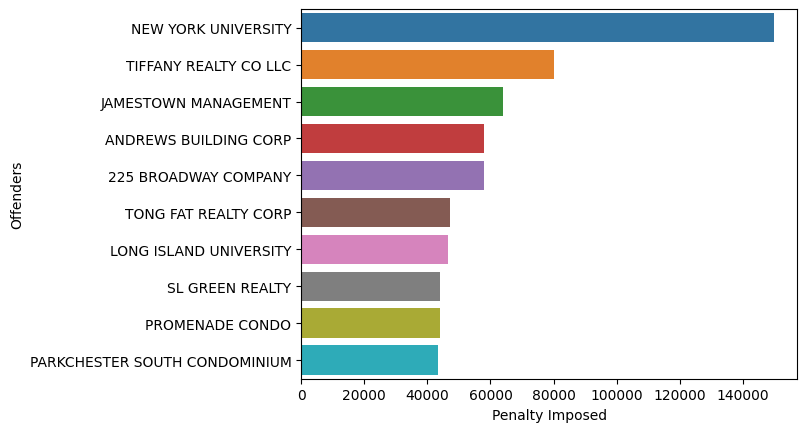

In [ ]:
top_offenders_plot = sns.barplot(data=top_offenders,
            x='Penalty Imposed',
            y='Respondent Last Name',
            hue= 'Respondent Last Name',
            legend=False)
plt.ylabel('Offenders')

In [ ]:
penalty_per_building = violations_df.groupby(['Respondent Last Name', 'address'])['Penalty Imposed'].sum().sort_values(ascending=False)

top_offending_buildings = penalty_per_building.reset_index().head(20)
top_offending_buildings

,Respondent Last Name,address,Penalty Imposed
0,TIFFANY REALTY CO LLC,130 HAVEMEYER ST,80000
1,JAMESTOWN MANAGEMENT,75 9TH AVE,64000
2,225 BROADWAY COMPANY,225 BROADWAY,58000
3,PROMENADE CONDO,89 JOHN STREET,44000
4,SL GREEN REALTY,16 COURT ST,43000
5,VORNADO LF 50 WEST 57TH STREET,50 W 57TH ST,42500
6,D-AHN DEVELOPMENTS LLC,25-22 ASTORIA BLVD,41000
7,675 OWNERSHIP LLC,675 6TH AVE,40000
8,ESRT 501 SEVENTH AVENUE L L C,501 7TH AVE,39500
9,RICHMOND MEDICAL CENTER,355 BARD AVE,37500


Text(0, 0.5, 'Buildings')

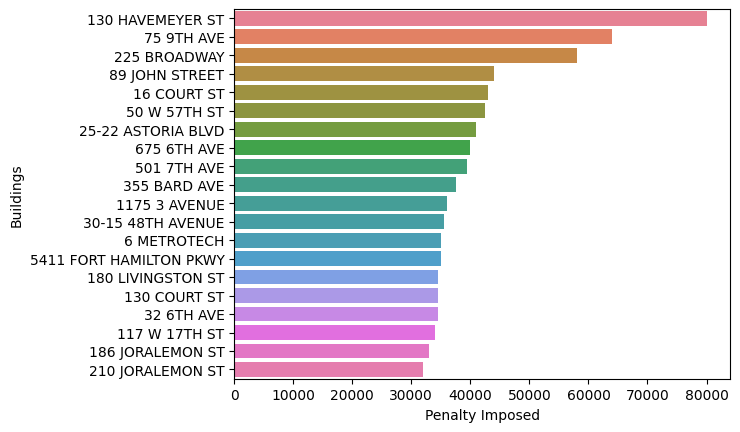

In [ ]:
top_offending_buildings_plot = sns.barplot(data=top_offending_buildings,
            x='Penalty Imposed',
            y='address',
            hue= 'Respondent Last Name',
            legend=False)
plt.ylabel('Buildings')

In [ ]:
penalty_per_type = violations_df.groupby([ 'violation_code', 'law_section'])['Penalty Imposed'].sum().sort_values(ascending=False).reset_index()
penalty_per_type.head(10)

,violation_code,law_section,Penalty Imposed
0,AH8S,24 RCNY §8-05(f)(3),4035670
1,AH8L,24 RCNY §8-05(c)(3),1981290
2,AH8C,24 RCNY §8-04(a),1919400
3,AH8R,24 RCNY §8-05(f)(2),1893370
4,AH8D,24 RCNY §8-04(b),1481500
5,AH8T,24 RCNY §8-05(f)(4),1355720
6,AH8A,24 RCNY §8-03,1028350
7,AH8B,24 RCNY §8-03,989500
8,AH8F,24 RCNY §8-04(d),965000
9,AH8U,24 RCNY §8-05(f)(5),812590


Text(0.5, 0, 'Cumulative Fines Imposed Citywide (Millions)')

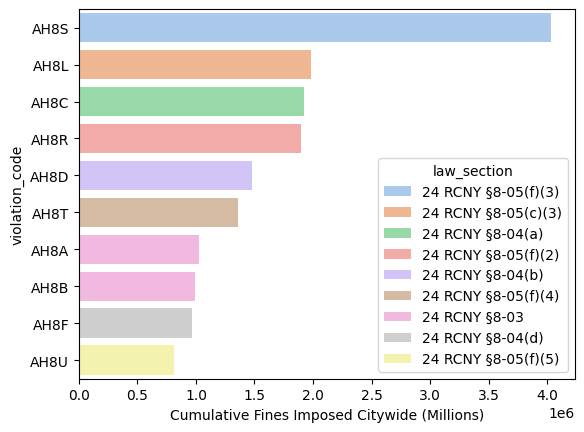

In [ ]:
top_violations_plot = sns.barplot(data=penalty_per_type.head(10),
            x='Penalty Imposed',
            y='violation_code',
            hue='law_section',
            palette= 'pastel',
            legend=True)

plt.xlabel("Cumulative Fines Imposed Citywide (Millions)")

## NYU

In [ ]:
#These are common variables used in the all of the following analyses
compliance_states = ['All Terms Met', 'Penalty Due']
pastels = sns.color_palette('pastel')

In [ ]:
nyu_df = violations_df[(violations_df['Respondent Last Name'] == 'NEW YORK UNIVERSITY')]
nyu_df['Violation Date'] = pd.to_datetime(nyu_df['Violation Date'])

/tmp/ipykernel_5472/1046180512.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  nyu_df['Violation Date'] = pd.to_datetime(nyu_df['Violation Date'])


In [ ]:
nyu_df['Penalty Imposed'].sum()

np.int64(149720)

In [ ]:
nyu_address_book_df = nyu_df['address'].unique()
nyu_address_book_df

array(['75 3RD AVE', '100 WASHINGTON SQ EAST', '34 STUYVESANT ST',
       '6 METROTECH', '334 E 25TH ST', '540 FIRST AVENUE',
       '522 FIRST AVENUE', '20 COOPER SQ', '251 MERCER ST',
       '726 BROADWAY', '33 WASHINGTON SQ WEST', '110 E 14TH ST',
       '55 E 10TH ST', '7 E 10TH ST', '7 E 12TH ST', '421 1ST AVE',
       '345 E 24TH ST', '1 E 78TH ST', '1 WASHINGTON SQ NORTH',
       '79 WASHINGTON SQ EAST', '5 UNIVERSITY PL', '120 W 15TH ST',
       '53 WASHINGTON SQUARE SOUTH', '433 1ST AVE', '140 E 14TH ST',
       '101 JOHNSON ST', '246 MERCER STREET', '383 LAFAYETTE ST',
       '60 5TH AVE', '14 E 78TH ST', '40 W 4TH ST', '708 BROADWAY'],
      dtype=object)

In [ ]:
nyu_buildings = nyu_df.groupby(['address'])['Penalty Imposed'].sum()
nyu_buildings.sort_values(ascending=False)

,Penalty Imposed
address,
6 METROTECH,35030
726 BROADWAY,14500
140 E 14TH ST,11530
100 WASHINGTON SQ EAST,10500
345 E 24TH ST,8030
110 E 14TH ST,6120
33 WASHINGTON SQ WEST,6030
79 WASHINGTON SQ EAST,6000
708 BROADWAY,6000


In [ ]:
print(nyu_df['Compliance Status'].value_counts())

Compliance Status
All Terms Met    233
Penalty Due       18
Name: count, dtype: int64


In [ ]:
nyu_compliance_amounts  = nyu_df.groupby(['Compliance Status'])['Penalty Imposed'].sum()

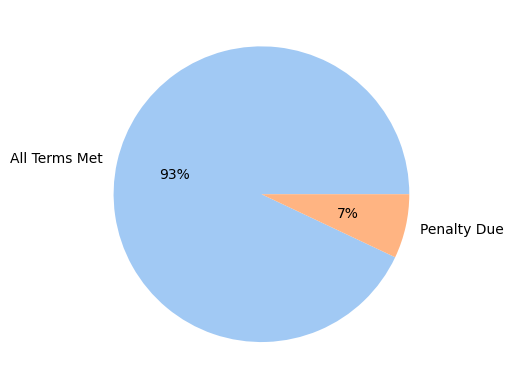

In [ ]:
plt.pie(nyu_compliance_amounts, labels= compliance_states, colors= pastels, autopct='%.0f%%')
plt.show()

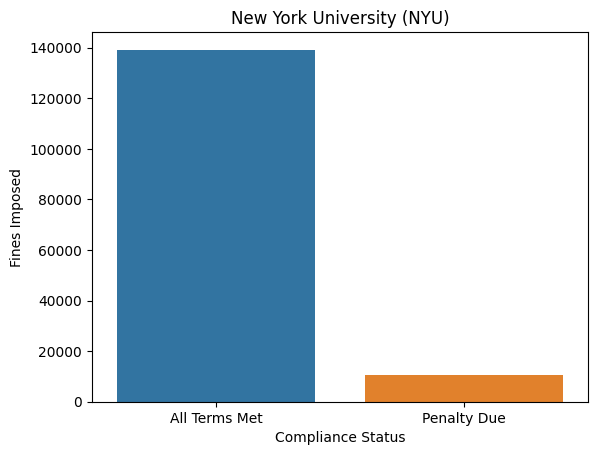

In [ ]:
nyu_bar = sns.barplot(x = compliance_states ,y = nyu_compliance_amounts, hue= compliance_states)
nyu_bar.set(xlabel='Compliance Status', ylabel='Fines Imposed', title="New York University (NYU)")
plt.show()

In [ ]:
nyu_top_violations = nyu_df.groupby(['violation_code', 'law_section'])['Penalty Imposed'].sum().sort_values(ascending=False)

In [ ]:
nyu_top_violations.head(5)

,,Penalty Imposed
violation_code,law_section,
AH8S,24 RCNY §8-05(f)(3),49150
AH8C,24 RCNY §8-04(a),26150
AH8L,24 RCNY §8-05(c)(3),19620
AH8R,24 RCNY §8-05(f)(2),11090
AH8U,24 RCNY §8-05(f)(5),10090


In [ ]:
nyu_dates = nyu_df.groupby(['Violation Date'])['Penalty Imposed'].sum()
nyu_dates.sort_index()

,Penalty Imposed
Violation Date,
2017-02-22,500
2017-03-07,4000
2017-03-08,1000
2017-03-09,13500
2017-03-13,5000
2017-03-16,2000
2017-03-17,530
2017-03-21,3090
2017-03-22,500


## TIFFANY REALTY CO LLC

In [ ]:
tiffany_df = violations_df[(violations_df['Respondent Last Name'] == 'TIFFANY REALTY CO LLC')]
tiffany_df['Violation Date'] = pd.to_datetime(tiffany_df['Violation Date'])

/tmp/ipykernel_567/1376388997.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  tiffany_df['Violation Date'] = pd.to_datetime(tiffany_df['Violation Date'])


In [ ]:
tiffany_df['Penalty Imposed'].sum()

np.int64(85000)

In [ ]:
print(tiffany_df['address'].unique())

['130 HAVEMEYER ST']


In [ ]:
print(tiffany_df['Compliance Status'].value_counts())

Compliance Status
All Terms Met    69
Penalty Due      26
Name: count, dtype: int64


In [ ]:
tiffany_compliance_amounts = tiffany_df.groupby(['Compliance Status'])['Penalty Imposed'].sum()

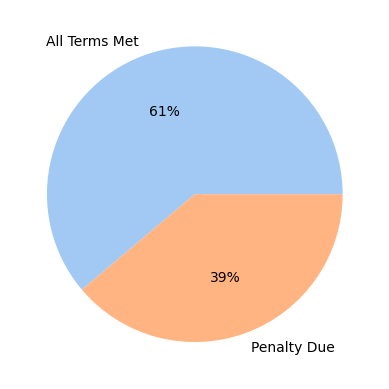

In [ ]:
plt.pie(tiffany_compliance_amounts, labels= compliance_states, colors= pastels, autopct='%.0f%%')
plt.show()

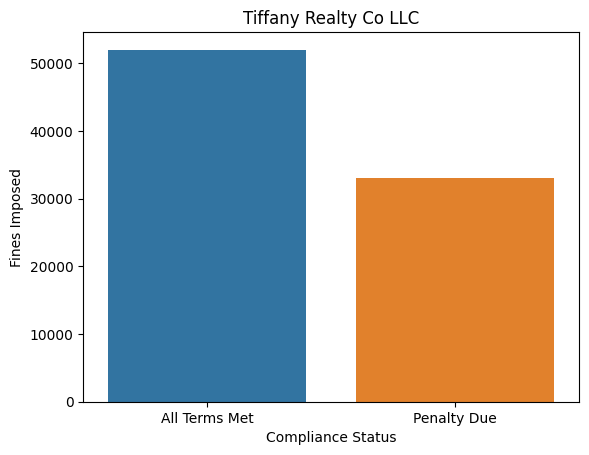

In [ ]:
tiffany_bar = sns.barplot(x = compliance_states ,y = tiffany_compliance_amounts, hue= compliance_states)
tiffany_bar.set(xlabel='Compliance Status', ylabel='Fines Imposed', title="Tiffany Realty Co LLC")
plt.show()

In [ ]:
tiffany_top_violations = tiffany_df.groupby(['violation_code', 'law_section'])['Penalty Imposed'].sum().sort_values(ascending=False)
tiffany_top_violations.head(5)

,,Penalty Imposed
violation_code,law_section,
AH8S,24 RCNY §8-05(f)(3),18000
AH8A,24 RCNY §8-03,14000
AH8C,24 RCNY §8-04(a),8000
AH8R,24 RCNY §8-05(f)(2),7000
AH8D,24 RCNY §8-04(b),6500


In [ ]:
tiffany_dates = tiffany_df.groupby(['Violation Date'])['Penalty Imposed'].sum()
tiffany_dates.sort_index()

,Penalty Imposed
Violation Date,
2017-01-20,12000
2018-01-03,12000
2019-08-06,4000
2020-08-25,13000
2021-06-30,6000
2022-04-08,4500
2023-01-26,10000
2024-05-01,4500
2024-09-12,2000


## JAMESTOWN MANAGEMENT



In [ ]:
jamestown_df = violations_df[(violations_df['Respondent Last Name'] == 'JAMESTOWN MANAGEMENT')]
jamestown_df['Violation Date'] = pd.to_datetime(jamestown_df['Violation Date'])

/tmp/ipykernel_567/4256070973.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  jamestown_df['Violation Date'] = pd.to_datetime(jamestown_df['Violation Date'])


In [ ]:
jamestown_df['Penalty Imposed'].sum()

np.int64(64000)

In [ ]:
print(jamestown_df['Compliance Status'].value_counts())

Compliance Status
All Terms Met    138
Name: count, dtype: int64


In [ ]:
print(jamestown_df['address'].unique())

['75 9TH AVE']


In [ ]:
jamestown_top_violations = jamestown_df.groupby(['violation_code', 'law_section'])['Penalty Imposed'].sum().sort_values(ascending=False)
jamestown_top_violations

,,Penalty Imposed
violation_code,law_section,
AH8S,24 RCNY §8-05(f)(3),9500
AH8C,24 RCNY §8-04(a),9000
AH8L,24 RCNY §8-05(c)(3),7500
AH8B,24 RCNY §8-03,7000
AH8R,24 RCNY §8-05(f)(2),7000
AH8T,24 RCNY §8-05(f)(4),6500
AH8G,24 RCNY §8-04(e),6000
AH8D,24 RCNY §8-04(b),5500
AH8A,24 RCNY §8-03,2000


In [ ]:
jamestown_dates = jamestown_df.groupby(['Violation Date'])['Penalty Imposed'].sum()
jamestown_dates.sort_index()

,Penalty Imposed
Violation Date,
2017-01-26,61000
2018-01-22,3000


##TONG FAT REALTY CORP

In [ ]:
tong_fat_df = violations_df[(violations_df['Respondent Last Name'] == 'TONG FAT REALTY CORP')]
tong_fat_df['Violation Date'] = pd.to_datetime(tong_fat_df['Violation Date'])

/tmp/ipykernel_567/1122351445.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  tong_fat_df['Violation Date'] = pd.to_datetime(tong_fat_df['Violation Date'])


In [ ]:
tong_fat_df['Penalty Imposed'].sum()

np.int64(47300)

In [ ]:
print(tong_fat_df['Compliance Status'].value_counts())

Compliance Status
All Terms Met    64
Name: count, dtype: int64


In [ ]:
print(tong_fat_df['address'].unique())

['245 GRAND ST' '101 CHRYSTIE ST' '250 GRAND ST']


In [ ]:
tong_fat_top_violations = tong_fat_df.groupby(['violation_code', 'law_section'])['Penalty Imposed'].sum().sort_values(ascending=False)
tong_fat_top_violations

,,Penalty Imposed
violation_code,law_section,
AH8S,24 RCNY §8-05(f)(3),9030
AH8A,24 RCNY §8-03,6030
AH8L,24 RCNY §8-05(c)(3),4530
AH8H,24 RCNY §8-05(a),4030
AH8F,24 RCNY §8-04(d),4030
AH8C,24 RCNY §8-04(a),4030
AH8R,24 RCNY §8-05(f)(2),4030
AH8D,24 RCNY §8-04(b),3530
AH8W,24 RCNY §8-06(b)(1),3500


In [ ]:
tong_fat_buildings = tong_fat_df.groupby(['address', 'Violation Date'])['Penalty Imposed'].sum()
tong_fat_buildings

address          Violation Date
101 CHRYSTIE ST  2017-09-28        11000
                 2018-04-23        10000
                 2019-04-02         6000
245 GRAND ST     2018-11-30            0
                 2023-08-15         6300
250 GRAND ST     2017-08-24         2000
                 2018-03-13        12000
Name: Penalty Imposed, dtype: int64

In [ ]:
tong_fat_dates = tong_fat_df.groupby(['Violation Date'])['Penalty Imposed'].sum()
tong_fat_dates.drop('2018-11-30')

,Penalty Imposed
Violation Date,
2017-08-24,2000
2017-09-28,11000
2018-03-13,12000
2018-04-23,10000
2019-04-02,6000
2023-08-15,6300


## ANDREWS BUILDING CORP

In [ ]:
andrews_df = violations_df[(violations_df['Respondent Last Name'] == 'ANDREWS BUILDING CORP')]
andrews_df['Violation Date'] = pd.to_datetime(andrews_df['Violation Date'])

/tmp/ipykernel_567/625429569.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  andrews_df['Violation Date'] = pd.to_datetime(andrews_df['Violation Date'])


In [ ]:
andrews_df['Penalty Imposed'].sum()

np.int64(58000)

In [ ]:
print(andrews_df['address'].unique())

['105 5TH AVE' '117 W 17TH ST' '141 W 13TH ST' '7 BOND ST']


In [ ]:
andrews_buildings = andrews_df.groupby(['address'])['Penalty Imposed'].sum()
andrews_buildings.sort_values(ascending=False)

,Penalty Imposed
address,
117 W 17TH ST,34000
105 5TH AVE,12000
141 W 13TH ST,12000
7 BOND ST,0


In [ ]:
print(andrews_df['Compliance Status'].value_counts())

Compliance Status
All Terms Met    44
Penalty Due      14
Name: count, dtype: int64


In [ ]:
andrews_compliance_amounts  = andrews_df.groupby(['Compliance Status'])['Penalty Imposed'].sum()

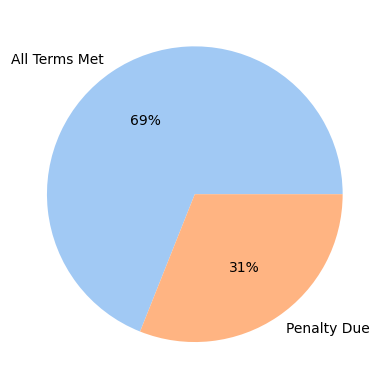

In [ ]:
plt.pie(andrews_compliance_amounts, labels= compliance_states, colors= pastels, autopct='%.0f%%')
plt.show()

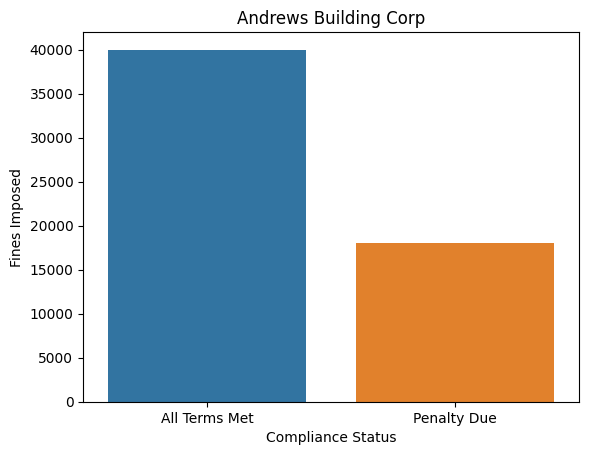

In [ ]:
andrews_bar = sns.barplot(x = compliance_states ,y = andrews_compliance_amounts, hue= compliance_states)
andrews_bar.set(xlabel='Compliance Status', ylabel='Fines Imposed', title= "Andrews Building Corp")
plt.show()

In [ ]:
andrews_top_violations = andrews_df.groupby(['violation_code', 'law_section'])['Penalty Imposed'].sum().sort_values(ascending=False)
andrews_top_violations.head(5)

,,Penalty Imposed
violation_code,law_section,
AH8S,24 RCNY §8-05(f)(3),12000
AH8A,24 RCNY §8-03,6000
AH8R,24 RCNY §8-05(f)(2),5500
AH8C,24 RCNY §8-04(a),5500
AH8D,24 RCNY §8-04(b),5000


In [ ]:
andrews_dates = andrews_df.groupby(['Violation Date'])['Penalty Imposed'].sum()
andrews_dates.drop(['2018-11-29','2021-05-11'] )

,Penalty Imposed
Violation Date,
2017-02-13,12000
2017-03-13,4000
2018-03-30,12000
2019-02-26,7000
2019-03-27,10000
2021-05-10,12000
2023-03-08,1000


##225 BROADWAY

In [ ]:
broadway225_df = violations_df[(violations_df['Respondent Last Name'] == '225 BROADWAY COMPANY')]
broadway225_df['Violation Date'] = pd.to_datetime(broadway225_df['Violation Date'])

/tmp/ipykernel_5472/3892969764.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  broadway225_df['Violation Date'] = pd.to_datetime(broadway225_df['Violation Date'])


In [ ]:
print(broadway225_df['Compliance Status'].value_counts())

Compliance Status
All Terms Met    99
Name: count, dtype: int64


In [ ]:
broadway225_top_violations = broadway225_df.groupby(['violation_code', 'law_section'])['Penalty Imposed'].sum().sort_values(ascending=False)
broadway225_top_violations

,,Penalty Imposed
violation_code,law_section,
AH8S,24 RCNY §8-05(f)(3),9000
AH8U,24 RCNY §8-05(f)(5),6000
AH8C,24 RCNY §8-04(a),6000
AH8D,24 RCNY §8-04(b),5000
AH8R,24 RCNY §8-05(f)(2),5000
AH8W,24 RCNY §8-06(b)(1),5000
AH8T,24 RCNY §8-05(f)(4),5000
AH8L,24 RCNY §8-05(c)(3),5000
AH8B,24 RCNY §8-03,4000


In [ ]:
broadway225_dates = broadway225_df.groupby(['Violation Date'])['Penalty Imposed'].sum()
broadway225_dates.sort_index()

,Penalty Imposed
Violation Date,
2017-04-17,53000
2019-06-20,0
2021-08-17,5000
